# Data Cleaning

In [1]:
import pandas as pd


In [2]:
olist_orders_df = pd.read_csv("olist_orders_dataset.csv")

olist_orders_df.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
917,5713bef560364e39ec1630ff62449492,793864114259d54262b38703f165acd2,delivered,2018-02-16 20:16:34,2018-02-20 07:15:29,2018-02-21 16:58:42,2018-03-12 23:56:17,2018-03-13 00:00:00
27290,2894cc15228a7127f78cb41017091b4c,1e0c217ef3faf0c5a171d075f1dd0b6f,delivered,2018-07-27 17:36:25,2018-07-27 17:50:24,2018-07-31 14:18:00,2018-08-03 12:39:05,2018-08-13 00:00:00
15682,bcdc0a3ff14ce03999d56620cb4e1a01,69bf47236b3b6d2da24ec0a6df47e9f9,delivered,2018-07-25 10:19:30,2018-07-26 05:35:18,2018-07-27 14:09:00,2018-08-01 21:52:44,2018-08-10 00:00:00
442,72344ea1113e3227494c465a64ae58aa,99907dc980230daa7bc0c7e6fb0b08fc,delivered,2018-01-13 15:43:58,2018-01-13 15:51:33,2018-01-15 23:04:22,2018-01-23 16:32:29,2018-02-08 00:00:00
13428,cc37a61fa8201c91170d102918162eec,2d6177d6c4d2effc7541364dd210d5ff,delivered,2018-08-19 23:20:49,2018-08-20 13:50:26,2018-08-20 15:07:00,2018-08-21 18:34:59,2018-08-23 00:00:00


In [3]:
olist_orders_df.shape

(99441, 8)

In [4]:
olist_orders_df['order_id'].nunique()

99441

In [5]:
olist_order_payments_df = pd.read_csv("olist_order_payments_dataset.csv")

olist_order_payments_df.sample(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
80890,de398ddd3c112d03a83aacdb609def35,1,credit_card,4,137.07
32389,0ddfbabc1c05f7dbef2c054efed7902f,1,credit_card,1,41.75
80948,1d03ab3055cbeb857235ddc26b6fc88a,1,debit_card,1,95.22
23714,e2e33b37d96ba30f106c15dd7f77c8bb,2,voucher,1,48.69
24376,61fc6c3134054ef03e72d9e1f9b5d4fd,1,credit_card,5,106.80


In [6]:
olist_order_payments_df.shape

(103886, 5)

In [7]:
olist_p1_df = pd.merge(olist_orders_df,olist_order_payments_df,on="order_id")

olist_p1_df.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
62662,e365857ddb17a012e5120ac8ff489d5a,ac1e3b5b6111c2cfa405cf267cab3942,delivered,2017-11-24 12:33:04,2017-11-24 14:52:55,2017-12-05 01:57:03,2017-12-12 18:15:47,2017-12-14 00:00:00,1,credit_card,1,113.62
87486,55aa5052d111a948144ba6bcbc4016ef,236208b57e73c7feb1d9983c80982ad6,delivered,2017-07-11 19:38:14,2017-07-11 19:50:12,2017-07-13 08:36:19,2017-07-17 19:32:56,2017-07-31 00:00:00,1,credit_card,1,71.82
39988,0aa3718b7db60c5ebec88b485cb975db,aa6bbe83912aa4d9762752cf237ac30e,delivered,2018-07-13 01:11:10,2018-07-14 02:35:20,2018-07-16 13:48:00,2018-07-23 13:22:54,2018-07-27 00:00:00,1,boleto,1,41.36
94483,9f978ecad138d859f6e9e08ed6b7cbda,05514af0c7b72bac8a4515ff7d4cd9e2,delivered,2018-07-05 19:26:53,2018-07-05 19:35:17,2018-07-06 11:16:00,2018-07-26 17:18:40,2018-08-08 00:00:00,1,debit_card,1,100.69
80539,046cb513a5ed6d4f7506af8f88636609,14ed9dcdbbcf33c3e561dfdd374373d8,delivered,2018-06-24 23:13:35,2018-06-24 23:34:10,2018-06-25 14:44:00,2018-06-28 18:42:02,2018-07-11 00:00:00,1,credit_card,2,69.06


In [8]:
olist_p1_df.shape

(103886, 12)

In [9]:
olist_p1_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 175
order_delivered_carrier_date     1888
order_delivered_customer_date    3132
order_estimated_delivery_date       0
payment_sequential                  0
payment_type                        0
payment_installments                0
payment_value                       0
dtype: int64

In [10]:
olist_p1_df.isnull().mean()*100

order_id                         0.000000
customer_id                      0.000000
order_status                     0.000000
order_purchase_timestamp         0.000000
order_approved_at                0.168454
order_delivered_carrier_date     1.817377
order_delivered_customer_date    3.014843
order_estimated_delivery_date    0.000000
payment_sequential               0.000000
payment_type                     0.000000
payment_installments             0.000000
payment_value                    0.000000
dtype: float64

In [11]:
olist_p1_df.duplicated().sum()

np.int64(0)

In [12]:
olist_p1_df.duplicated(subset=["order_id" , "customer_id"]).sum()

np.int64(4446)

In [13]:
olist_p1_df.duplicated(subset=["order_id" , "customer_id"],keep=False).sum()

np.int64(7407)

In [14]:
olist_p1_df[olist_p1_df.duplicated(subset=["order_id" , "customer_id"])]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,1,18.59
12,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,1,credit_card,1,8.34
23,83018ec114eee8641c97e08f7b4e926f,7f8c8b9c2ae27bf3300f670c3d478be8,delivered,2017-10-26 15:54:26,2017-10-26 16:08:14,2017-10-26 21:46:53,2017-11-08 22:22:00,2017-11-23 00:00:00,3,voucher,1,24.86
24,83018ec114eee8641c97e08f7b4e926f,7f8c8b9c2ae27bf3300f670c3d478be8,delivered,2017-10-26 15:54:26,2017-10-26 16:08:14,2017-10-26 21:46:53,2017-11-08 22:22:00,2017-11-23 00:00:00,1,credit_card,1,5.96
...,...,...,...,...,...,...,...,...,...,...,...,...
103773,0572c996d9b4a7645bb071a158a64bbb,874b661d62c1e74aafa401942f9d94cb,delivered,2017-11-20 21:53:20,2017-11-20 22:07:27,2017-11-22 00:32:47,2017-11-27 21:28:53,2017-12-11 00:00:00,1,credit_card,1,42.59
103782,4bafa54db6b060da198f23f810835969,48094f58f03bec9519bd0e004ce460df,delivered,2018-04-05 14:46:51,2018-04-05 15:09:52,2018-04-07 01:32:58,2018-04-30 21:41:07,2018-05-14 00:00:00,2,voucher,1,49.32
103783,4bafa54db6b060da198f23f810835969,48094f58f03bec9519bd0e004ce460df,delivered,2018-04-05 14:46:51,2018-04-05 15:09:52,2018-04-07 01:32:58,2018-04-30 21:41:07,2018-05-14 00:00:00,3,voucher,1,8.13
103877,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-04 19:57:37,2017-10-04 20:07:14,2017-10-05 16:52:52,2017-10-20 20:25:45,2017-11-07 00:00:00,2,voucher,1,64.37


In [15]:
olist_p1_df.drop_duplicates()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,credit_card,3,179.12
...,...,...,...,...,...,...,...,...,...,...,...,...
103881,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,1,credit_card,3,85.08
103882,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,1,credit_card,3,195.00
103883,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,1,credit_card,5,271.01
103884,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,1,credit_card,4,441.16


In [16]:
olist_p1_df.dtypes

order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_approved_at                    str
order_delivered_carrier_date         str
order_delivered_customer_date        str
order_estimated_delivery_date        str
payment_sequential                 int64
payment_type                         str
payment_installments               int64
payment_value                    float64
dtype: object

In [17]:
df_orders_payments=pd.DataFrame()
df_orders_payments[["order_id","customer_id","order_purchase_timestamp"]]=olist_p1_df[["order_id","customer_id","order_purchase_timestamp"]]

In [18]:
df_orders_payments.shape

(103886, 3)

In [19]:
df_orders_payments.drop_duplicates(subset="order_id",inplace=True)

In [20]:
df_orders_payments.shape

(99440, 3)

In [21]:
df_orders_payments

,order_id,customer_id,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39
...,...,...,...
103881,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,2017-03-09 09:54:05
103882,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-06 12:58:58
103883,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-27 14:46:43
103884,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27


In [22]:
df_orders_payments.sample(5)

,order_id,customer_id,order_purchase_timestamp
24204,02f1d13053a2833d022b8921ee3411a3,d11acaa2c66d92618088456a9ab09d11,2018-08-02 12:05:22
27221,9ca1180e941195f37062a7d063cf2767,92ae6bb4c23948ab0f4aec41737c166d,2018-03-05 14:04:48
93759,a138937aa3e8370a29b43014b9dac5ea,2c032031470d729f0d39269f7ddeea0a,2017-11-24 14:24:18
44159,10487ca7dcab9ddc13cd4ee2fe1ef2f7,6375f291ca662cda38bba47ce8d767f1,2017-04-06 10:31:58
65455,3e28393f83efb34c56df093513721d60,72634020787e70502d6f4f43ce34f543,2017-07-13 12:17:56


In [23]:
df_orders_payments["total_payment_value"] = (
    olist_p1_df.groupby("order_id")["payment_value"].transform("sum")
)

In [24]:
df_orders_payments[df_orders_payments["order_id"]=="e481f51cbdc54678b7cc49136f2d6af7"]

,order_id,customer_id,order_purchase_timestamp,total_payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,38.71


In [25]:
df_orders_payments.shape

(99440, 4)

In [26]:
df_orders_payments.order_id.nunique()

99440

In [27]:
customers_df = pd.read_csv("olist_customers_dataset.csv")

customers_df.sample(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
97701,a27c58025590f2b1b7c03a82eb6637d5,3aee46f9eb19797d64771269a1e979d6,20260,rio de janeiro,RJ
62277,b4b0ce0c3cfac1b0d240823681496307,59ad0211f363428b2d44b121725e87b2,79813,dourados,MS
4078,9f3138bc272b22e8eb38f4819728ef01,78d4b99ae47914661abd3c888cb94efb,12231,sao jose dos campos,SP
82876,5fffdb430f630b75465a5d5dfd37ab44,d95c4b13476f7a25ed6b161fd23796b8,48520,canudos,BA
17833,1be55980a49eb83dda71ae61abe091a1,b4be9c884923b47742c6ab3e866c1e30,21235,rio de janeiro,RJ


In [28]:
customers_df.shape

(99441, 5)

In [29]:
customers_df.customer_unique_id.value_counts()

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
                                    ..
1a29b476fee25c95fbafc67c5ac95cf8     1
d52a67c98be1cf6a5c84435bd38d095d     1
e9f50caf99f032f0bf3c55141f019d99     1
73c2643a0a458b49f58cea58833b192e     1
84732c5050c01db9b23e19ba39899398     1
Name: count, Length: 96096, dtype: int64

In [30]:
customer_orders_payments_df=pd.merge(df_orders_payments,customers_df,on="customer_id",how='inner')

In [31]:
customer_orders_payments_df

,order_id,customer_id,order_purchase_timestamp,total_payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,38.71,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,72.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,28.62,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
...,...,...,...,...,...,...,...,...
99435,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,2017-03-09 09:54:05,85.08,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP
99436,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,2018-02-06 12:58:58,195.00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP
99437,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,2017-08-27 14:46:43,271.01,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA
99438,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2018-01-08 21:28:27,441.16,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ


In [32]:
customer_orders_payments_df.dtypes

order_id                        str
customer_id                     str
order_purchase_timestamp        str
total_payment_value         float64
customer_unique_id              str
customer_zip_code_prefix      int64
customer_city                   str
customer_state                  str
dtype: object

In [33]:
customer_orders_payments_df['order_purchase_timestamp']=pd.to_datetime(customer_orders_payments_df['order_purchase_timestamp']).dt.normalize()

In [34]:
customer_orders_payments_df.dtypes

order_id                               str
customer_id                            str
order_purchase_timestamp    datetime64[us]
total_payment_value                float64
customer_unique_id                     str
customer_zip_code_prefix             int64
customer_city                          str
customer_state                         str
dtype: object

In [35]:
customer_orders_payments_df['order_purchase_timestamp'].sample(5)

29101   2017-10-19
36402   2018-03-31
14378   2018-03-11
88452   2018-08-13
98166   2018-06-21
Name: order_purchase_timestamp, dtype: datetime64[us]

# Analysis

In [36]:
newest_date=customer_orders_payments_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
newest_date

Timestamp('2018-10-18 00:00:00')

In [37]:
filtering_recency=(newest_date-customer_orders_payments_df['order_purchase_timestamp']).dt.days<90

In [38]:
customer_orders_payments_df[filtering_recency]

,order_id,customer_id,order_purchase_timestamp,total_payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
13,5ff96c15d0b717ac6ad1f3d77225a350,19402a48fe860416adf93348aba37740,2018-07-25,32.70,e2dfa3127fedbbca9707b36304996dab,4812,sao paulo,SP
24,f3e7c359154d965827355f39d6b1fdac,62b423aab58096ca514ba6aa06be2f98,2018-08-09,104.11,9c9242ad7f1b52d926ea76778e1c0c57,18052,sorocaba,SP
34,b276e4f8c0fb86bd82fce576f21713e0,cf8ffeddf027932e51e4eae73b384059,2018-07-29,188.41,6cbe8a392b76916e84c2faf69d0d0da0,13454,santa barbara d'oeste,SP
...,...,...,...,...,...,...,...,...
99393,079c9f53e6c3253320db701a645b0b9a,e5e0698e95094be297436cbd55c2dcad,2018-08-09,98.23,531d6ca1ecce995a2317a0ca559e8c61,31030,belo horizonte,MG
99394,5597332b7eded552f104108f22b023e4,aaa423fb52f4106f477683490cbd5845,2018-08-15,36.46,8a898880a61e551c80bacadfb4356255,6449,barueri,SP
99395,b3112ca67f3afd4e20cf2ee91fc4f804,6f83c71b6c044fb156d697d4130fe9b5,2018-08-02,239.50,f690f0caffab80b6f849f08ba1692925,9330,maua,SP
99406,c2af225ac9a68a3c24500aa6fab006aa,f93c9e539a9705a57902c625b611e90c,2018-08-20,43.87,a3adfb1ef257529c6abe81be7726a63f,1454,sao paulo,SP


In [39]:
customer_orders_payments_df[filtering_recency].customer_unique_id.nunique()

9077

In [40]:
customer_orders_payments_df['customer_unique_id'].nunique()

96095

In [41]:
customer_orders_payments_df['customer_unique_id'].value_counts().value_counts()

count
1     93098
2      2745
3       203
4        30
5         8
6         6
7         3
17        1
9         1
Name: count, dtype: int64

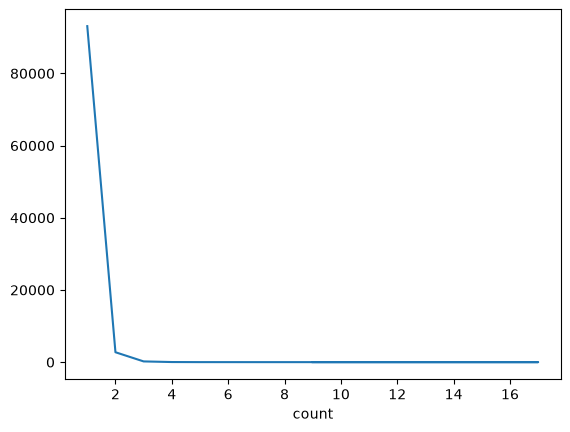

In [42]:
customer_orders_payments_df['customer_unique_id'].value_counts().value_counts().plot();

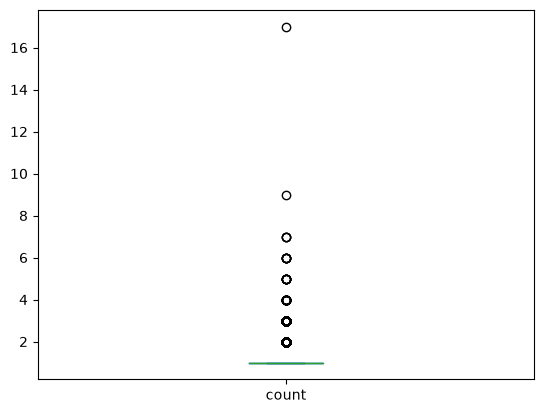

In [71]:
customer_orders_payments_df['customer_unique_id'].value_counts().plot(kind='box');

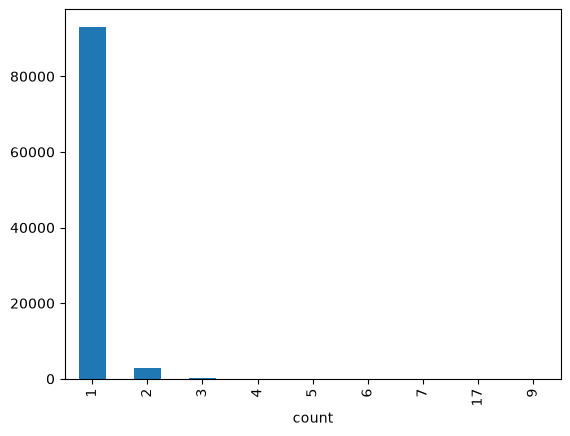

In [43]:
customer_orders_payments_df['customer_unique_id'].value_counts().value_counts().plot(kind='bar');

In [69]:
(customer_orders_payments_df['customer_unique_id'].value_counts()>=2).sum()

np.int64(2997)

In [68]:
100*(customer_orders_payments_df['customer_unique_id'].value_counts()>=2).mean()

np.float64(3.1187886986835944)

**Percentage of ordering 2 or more is 3.12 %**


In [66]:
# used AI to generate this code to apply both conditions of the RFM on the dataset

frequent_customers = (customer_orders_payments_df['customer_unique_id'].value_counts())

customers_2_plus = frequent_customers[frequent_customers >= 2].index

recent_customers = (customer_orders_payments_df.loc[filtering_recency,'customer_unique_id'].unique())

loyal_customers = set(customers_3_plus) & set(recent_customers)

len(loyal_customers)

326

In [50]:
customer_orders_payments_df['customer_unique_id'].value_counts()

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
ca77025e7201e3b30c44b472ff346268     7
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
                                    ..
6359f309b166b0196dbf7ad2ac62bb5a     1
da62f9e57a76d978d02ab5362c509660     1
737520a9aad80b3fbbdad19b66b37b30     1
5097a5312c8b157bb7be58ae360ef43c     1
60350aa974b26ff12caad89e55993bd6     1
Name: count, Length: 96095, dtype: int64

In [51]:
customer_orders_payments_df[filtering_recency]['customer_unique_id'].value_counts().value_counts()

count
1    8975
2      93
3       7
4       2
Name: count, dtype: int64

## Customer Lifetime Value

In [52]:
CLV_df=customer_orders_payments_df.groupby('customer_unique_id').total_payment_value.agg(['sum','count','mean'])

In [53]:
CLV_df.sort_values(by='mean',ascending=False)

,sum,count,mean
customer_unique_id,,,
0a0a92112bd4c708ca5fde585afaa872,13664.08,1,13664.08
763c8b1c9c68a0229c42c9fc6f662b93,7274.88,1,7274.88
dc4802a71eae9be1dd28f5d788ceb526,6929.31,1,6929.31
459bef486812aa25204be022145caa62,6922.21,1,6922.21
ff4159b92c40ebe40454e3e6a7c35ed6,6726.66,1,6726.66
...,...,...,...
b33336f46234b24a613ad9064d13106d,10.89,1,10.89
bd06ce0e06ad77a7f681f1a4960a3cc6,10.07,1,10.07
317cfc692e3f86c45c95697c61c853a6,9.59,1,9.59


**2 customers have orders with 0 total cost, is it input error in the data, special offers or exploiting glitch?**

## days between orders

In [54]:
average_days_df = customer_orders_payments_df.sort_values(["customer_unique_id", "order_purchase_timestamp"])


In [55]:
average_days_df["order_number"] = (average_days_df.groupby("customer_unique_id").cumcount() + 1)


In [56]:
average_days_df["previous_order_date"] = (average_days_df.groupby("customer_unique_id")["order_purchase_timestamp"].shift(1))


In [57]:
average_days_df["days_between_orders"] = (average_days_df["order_purchase_timestamp"]-average_days_df["previous_order_date"]).dt.days

In [58]:
average_days_df[average_days_df["order_number"]==2].days_between_orders.mean()

np.float64(80.34834834834835)

## Single order customers

In [59]:
100*(customer_orders_payments_df['customer_unique_id'].value_counts()==1).mean()

np.float64(96.88121130131641)

**96.88 % of the customers only ordered once** 

In [60]:
CLV_df[CLV_df['count']>1]['sum'].mean()

np.float64(314.9892258925592)

In [61]:
CLV_df[CLV_df['count']==1]['sum'].mean()

np.float64(161.81711110872413)

In [62]:
CLV_differance = CLV_df[CLV_df['count']>1]['sum'].mean()-CLV_df[CLV_df['count']==1]['sum'].mean()

In [63]:
CLV_df['mean'].count()*0.05*CLV_differance

np.float64(735953.7185076316)

**Turning 5 % of the single order customers to a repeat customers will return an estimated revenue of 735,954 R$**